# Simulate amplitude damping using collisional circuit

0.1


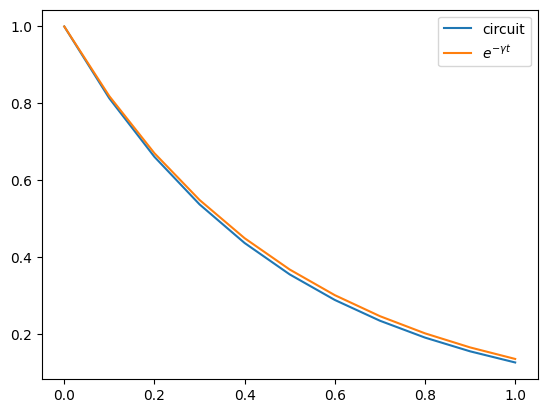

In [6]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

sp = qt.sigmap()
sm = qt.sigmam()
gamma = 2.0
tlist = np.linspace(0,1,11)
dt = tlist[1]
print(dt)

H = qt.tensor(sp,sm) + qt.tensor(sm,sp)
U = qt.Qobj.expm(-1j * np.sqrt(gamma *dt) *H ) 

rho0 = qt.tensor( qt.basis(2,0), qt.basis(2,1))
rho0 = qt.ket2dm(rho0)

rhost = [rho0.ptrace(0)]
rhosti = rho0.ptrace(0)
for i in range(len(tlist)-1):
    rhoti = qt.tensor(rhosti, qt.ket2dm( qt.basis(2,1)) )
    rhosti = (U * rhoti * U.dag()).ptrace(0)
    rhost.append(rhosti)

plt.plot(tlist, [ np.real( rho[0,0]) for rho in rhost   ], label="circuit")
plt.plot(tlist, np.exp(-gamma*tlist), label=r"$e^{-\gamma t}$")
plt.legend()

# Cascaded coupling with collisional circuit
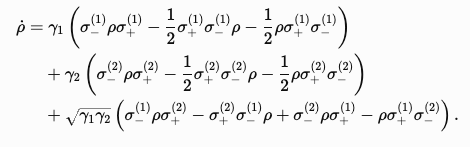

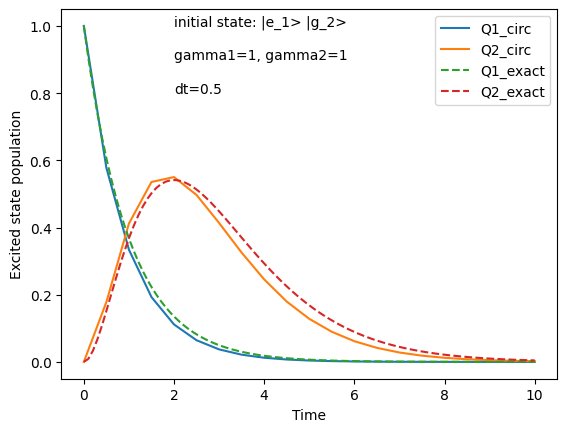

In [6]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

sp = qt.sigmap()
sm = qt.sigmam()
s0 = qt.qeye(2)

####### Exact Master equation 
gamma1 = 1
gamma2 = 1

ve = qt.basis(2,0)
vg = qt.basis(2,1)
rhoe = qt.ket2dm(ve)
rhog = qt.ket2dm(vg)

sp1 = qt.tensor(sp,s0)
sm1 = qt.tensor(sm,s0)
sp2 = qt.tensor(s0,sp)
sm2 = qt.tensor(s0,sm)

L  = (gamma1/2) * ( 2*qt.spre(sm1)*qt.spost(sp1) - qt.spre(sp1*sm1) -qt.spost(sp1*sm1))
L += (gamma2/2) * ( 2*qt.spre(sm2)*qt.spost(sp2) - qt.spre(sp2*sm2) -qt.spost(sp2*sm2))
L += np.sqrt(gamma1*gamma2) * ( qt.spre(sm1)*qt.spost(sp2) + qt.spre(sm2)*qt.spost(sp1)
                                - qt.spre(sp2*sm1) - qt.spost(sp1*sm2) )
rho0_exact = qt.tensor( rhoe, rhog) 
tlist_exact = np.linspace(0,10,100)
rhot_exact = qt.mesolve(L,rho0_exact,tlist_exact).states



# 1 | 2 | e

H1e = qt.tensor(sm,s0,sp) + qt.tensor(sp,s0,sm)
H2e = qt.tensor(s0,sm,sp) + qt.tensor(s0,sp,sm)


#####Circuit model approximation

tlist_circ = np.linspace(0,10,21)
dt = tlist_circ[1]

U1e = qt.Qobj.expm(-1j *np.sqrt(gamma1*dt) * H1e)
U2e = qt.Qobj.expm(-1j *np.sqrt(gamma2*dt) * H2e)

rho0_circ = qt.tensor( rhoe,rhog,rhog)
rhost_circ = [rho0_circ.ptrace([0,1])]
rhosti_circ = rho0_circ.ptrace([0,1])

for i in range(len(tlist_circ)-1):
    rhoti_circ = qt.tensor(rhosti_circ, rhog )
    rhosti_circ = (U2e * U1e * rhoti_circ * U1e.dag()*U2e.dag()).ptrace([0,1])
    rhost_circ.append(rhosti_circ)




plt.plot(tlist_circ, [ np.real( rho.ptrace(0)[0,0]) for rho in rhost_circ   ], label="Q1_circ")
plt.plot(tlist_circ, [ np.real( rho.ptrace(1)[0,0]) for rho in rhost_circ   ], label="Q2_circ")

plt.plot( tlist_exact, [ np.real( rho.ptrace(0)[0,0] ) for rho in rhot_exact],"--", label="Q1_exact" )
plt.plot( tlist_exact, [ np.real( rho.ptrace(1)[0,0] ) for rho in rhot_exact],"--", label="Q2_exact" )


plt.text(2,1,"initial state: |e_1> |g_2>")
plt.text(2,0.9,"gamma1="+str(gamma1)+", gamma2="+str(gamma2))
plt.text(2,0.8,"dt="+str(dt))

plt.xlabel("Time")
plt.ylabel("Excited state population")
plt.legend()